# Klasifikasi DemogPairs Menggunakan ViT (Umur) & Gaussian Naive Bayes

In [1]:
import numpy as np
import utils as u
import joblib
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import StratifiedKFold, ParameterGrid
from imblearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

joblib.parallel_backend('threading')

C:\Users\Rezky\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Dataset

In [2]:
data = u.load_demogpairs()
pd.DataFrame(data)

,db_code,image_path,full_path,label,label_idx
0,CWF,able_wanamakok/002.jpg,dataset/demogpairs/images/able_wanamakok/002.jpg,Asian_Females,5
1,CWF,able_wanamakok/004.jpg,dataset/demogpairs/images/able_wanamakok/004.jpg,Asian_Females,5
2,CWF,able_wanamakok/007.jpg,dataset/demogpairs/images/able_wanamakok/007.jpg,Asian_Females,5
3,CWF,able_wanamakok/008.jpg,dataset/demogpairs/images/able_wanamakok/008.jpg,Asian_Females,5
4,CWF,able_wanamakok/012.jpg,dataset/demogpairs/images/able_wanamakok/012.jpg,Asian_Females,5
...,...,...,...,...,...
10795,CWF,zachary_quinto/177.jpg,dataset/demogpairs/images/zachary_quinto/177.jpg,White_Males,3
10796,CWF,zachary_quinto/214.jpg,dataset/demogpairs/images/zachary_quinto/214.jpg,White_Males,3
10797,CWF,zachary_quinto/217.jpg,dataset/demogpairs/images/zachary_quinto/217.jpg,White_Males,3
10798,CWF,zachary_quinto/218.jpg,dataset/demogpairs/images/zachary_quinto/218.jpg,White_Males,3


## Load Fitur

In [3]:
features = joblib.load('features/demogpairs_vit-age.pkl')
print('Jumlah fitur per gambar:', np.array(features[list(features.keys())[0]]).shape[0])

Jumlah fitur per gambar: 768


## Split Data

In [4]:
X = np.array([features[d['image_path']] for d in data])
y = np.array([d['label_idx'] for d in data])
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
print((len(X_train), len(X_test)))

(8640, 2160)


## Kombinasi Parameter

In [5]:
var_smoothing_values = np.logspace(-9, 2, 40)  # dari 1e-9 sampai 1e2, 40 nilai

grid_params = [
    {
        'classifier': [GaussianNB()],
        'classifier__var_smoothing': var_smoothing_values
    }
]

pipeline = Pipeline(steps=[
    ('classifier', None)
])

skv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    'accuracy': 'accuracy', 
    'f1': 'f1_macro', 
    'precision': 'precision_macro', 
    'recall': 'recall_macro',
    'roc_auc_ovr': 'roc_auc_ovr'
}

grid_models = {}
for params in grid_params:
    key = str(params['classifier'][0]).split('(')[0]
    grid_models[key] = GridSearchCV(
        estimator=pipeline,
        param_grid=params,
        cv=skv, refit='accuracy',
        scoring=scoring, n_jobs=int(joblib.cpu_count() * 0.8),
        verbose=1, error_score='raise',
        return_train_score=True
    )
    print(f'{key}: {len(ParameterGrid(params))} kombinasi')

GaussianNB: 40 kombinasi


## Klasifikasi

Mengevaluasi model: GaussianNB
Fitting 5 folds for each of 40 candidates, totalling 200 fits


{'classifier': 'GaussianNB', 'classifier__var_smoothing': np.float64(1e-09)}


Accuracy  : 0.47129629629629627
Precision : 0.4863606604137562
Recall    : 0.4712962962962963
F1 Score  : 0.4561034625055623
              precision    recall  f1-score   support

           0       0.55      0.61      0.58       360
           1       0.54      0.36      0.43       360
           2       0.55      0.28      0.38       360
           3       0.43      0.59      0.50       360
           4       0.43      0.26      0.32       360
           5       0.42      0.72      0.53       360

    accuracy                           0.47      2160
   macro avg       0.49      0.47      0.46      2160
weighted avg       0.49      0.47      0.46      2160



Class,Accuracy,Precision,Recall,F1-Score
Black_Males,0.8518518518518519,0.5497512437810945,0.6138888888888889,0.5800524934383202
White_Females,0.8416666666666667,0.5375,0.35833333333333334,0.43
Asian_Males,0.8425925925925926,0.5543478260869565,0.2833333333333333,0.375
White_Males,0.799537037037037,0.42714570858283435,0.5944444444444444,0.49709639953542395
Black_Females,0.8189814814814815,0.4292237442922374,0.2611111111111111,0.32469775474956825
Asian_Females,0.787962962962963,0.4201954397394137,0.7166666666666667,0.5297741273100616


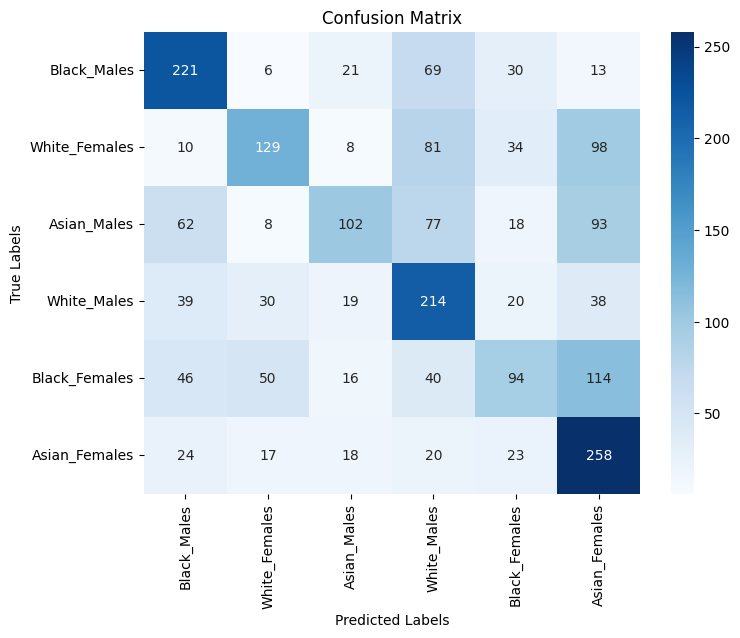

model_name,model_file_path,best_parameters,test_accuracy,test_f1,test_precision,test_recall,parameter_combinations
GaussianNB,models/clf_demogpairs_gnb_vit-age_GaussianNB.pkl,"{'classifier': 'GaussianNB', 'classifier__var_smoothing': np.float64(1e-09)}",0.47129629629629627,0.4561034625055623,0.4863606604137562,0.4712962962962963,40


In [6]:
evaluation_results, fold_results = u.evaluate_models(
    grid_models,
    X_train, y_train,
    X_test, y_test,
    model_prefix='models/clf_demogpairs_gnb_vit-age_',
    results_path='results/demogpairs_gnb_vit-age_'
)

sorted_results = pd.DataFrame(evaluation_results).sort_values(by='test_accuracy', ascending=False).to_dict('records')
u.html_br()
_dtable = u.display_table(sorted_results)

In [7]:
model, training_time = u.load_object('models/clf_demogpairs_gnb_vit-age_GaussianNB.pkl')
u.h(5, 'Waktu Pelatihan (Jobs)')
u.seconds_to_time(round(training_time))

{'input_seconds': 87.0,
 'days': 0,
 'hours': 0,
 'minutes': 1,
 'seconds': 27.0,
 'text': '0 hari 0 jam 1 menit 27.0 detik'}

In [8]:
u.h(5, 'Waktu Pelatihan')
times = [fr['Train Time Mean'] * 5 for fr in fold_results]
u.seconds_to_time(round(np.sum(times) + model.refit_time_))

{'input_seconds': 59.0,
 'days': 0,
 'hours': 0,
 'minutes': 0,
 'seconds': 59.0,
 'text': '0 hari 0 jam 0 menit 59.0 detik'}

In [9]:
_dtable = u.display_table(fold_results, n_items=[4, 4], column_widths=['5%', '45%', '5%', '5%', '5%', '5%', '5%', '5%', '5%', '5%', '5%', '5%'])

No,Params,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Accuracy Mean,F1 Score Mean,Precision Mean,Recall Mean,Train Time Mean
1,"{'classifier': 'GaussianNB', 'classifier__var_smoothing': np.float64(1e-09)}",0.4786,0.4826,0.4537,0.4711,0.4913,0.4755,0.4636,0.4849,0.4755,0.3341
2,"{'classifier': 'GaussianNB', 'classifier__var_smoothing': np.float64(1.9144819761699614e-09)}",0.4786,0.4826,0.4537,0.4711,0.4913,0.4755,0.4636,0.4849,0.4755,0.3305
3,"{'classifier': 'GaussianNB', 'classifier__var_smoothing': np.float64(3.665241237079626e-09)}",0.4786,0.4826,0.4537,0.4711,0.4913,0.4755,0.4636,0.4849,0.4755,0.2201
4,"{'classifier': 'GaussianNB', 'classifier__var_smoothing': np.float64(7.017038286703837e-09)}",0.4786,0.4826,0.4537,0.4711,0.4913,0.4755,0.4636,0.4849,0.4755,0.2979
...,...,...,...,...,...,...,...,...,...,...,...
37,"{'classifier': 'GaussianNB', 'classifier__var_smoothing': np.float64(14.251026703029963)}",0.3947,0.4005,0.3785,0.3848,0.3999,0.3917,0.3534,0.4478,0.3917,0.3066
38,"{'classifier': 'GaussianNB', 'classifier__var_smoothing': np.float64(27.283333764867695)}",0.3924,0.3981,0.3779,0.3837,0.3993,0.3903,0.3518,0.4468,0.3903,0.3014
39,"{'classifier': 'GaussianNB', 'classifier__var_smoothing': np.float64(52.233450742668325)}",0.3912,0.3976,0.3773,0.3819,0.3976,0.3891,0.3502,0.4462,0.3891,0.3061
40,"{'classifier': 'GaussianNB', 'classifier__var_smoothing': np.float64(100.0)}",0.3912,0.397,0.3785,0.3819,0.397,0.3891,0.3499,0.4464,0.3891,0.2821
